# 03 - Benchmark models

Fits the five benchmark forecasts (mean, naive, daily seasonal naive, weekly seasonal naive, drift) over a 24-hour horizon against the final-14-days test split, using the reusable functions in `appliance_energy.models.benchmarks` and `appliance_energy.evaluation` -- the same functions used by `scripts/run_pipeline.py`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data, evaluation, plotting
from appliance_energy.models import benchmarks

config.ensure_dirs()
hourly = data.load_hourly_data()
y = hourly[config.TARGET]

train, test = data.train_test_split_series(y, test_steps=config.TEST_STEPS)
horizon = len(test)

print("Train:", train.index.min(), "to", train.index.max(), f"({len(train)} rows)")
print("Test: ", test.index.min(), "to", test.index.max(), f"({len(test)} rows)")

Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00 (2954 rows)
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00 (336 rows)


## Forecasting problem definition

- **Target**: `Appliances` (hourly mean, Wh)
- **Forecast horizon**: 24 hours ahead
- **Train/test split**: final 14 days held out as test (`TEST_STEPS = 336`), everything before that is training data
- **Evaluation metrics**: MAE, RMSE, MASE (scaled by the in-sample daily seasonal-naive error), and Bias
- Every later model (SARIMAX, feature-based, foundation) must be compared against the **strongest benchmark**, not just against each other

## Fit benchmark forecasts

In [2]:
forecasts = {}

forecasts["mean"] = benchmarks.mean_forecast(train, horizon, test.index)
forecasts["naive"] = benchmarks.naive_forecast(train, horizon, test.index)
forecasts["seasonal_naive_daily"] = benchmarks.seasonal_naive_forecast(
    train, horizon, test.index, seasonality=config.DAILY_PERIOD
)
forecasts["seasonal_naive_weekly"] = benchmarks.seasonal_naive_forecast(
    train, horizon, test.index, seasonality=config.WEEKLY_PERIOD
)
forecasts["drift"] = benchmarks.drift_forecast(train, horizon, test.index)

list(forecasts.keys())

['mean', 'naive', 'seasonal_naive_daily', 'seasonal_naive_weekly', 'drift']

## Evaluate against the test period

In [3]:
results_df = evaluation.evaluate_all(forecasts, test, train, seasonality=config.DAILY_PERIOD)
results_df.round(3)

,model,MAE,RMSE,MASE,Bias
0,seasonal_naive_weekly,42.634,79.290,0.798,-10.818
1,mean,50.319,74.906,0.942,-3.109
2,seasonal_naive_daily,86.959,129.232,1.628,64.013
3,naive,250.640,258.820,4.692,247.763
4,drift,266.373,274.611,4.986,264.501


## Which benchmark is strongest?

The model with the lowest MASE below is the strongest benchmark.

In [4]:
strongest = results_df.iloc[0]
print(f"Strongest benchmark: {strongest['model']} (MASE={strongest['MASE']:.3f})")

Strongest benchmark: seasonal_naive_weekly (MASE=0.798)


## Plot forecasts against the actual test data

Saved figure to D:\UK ass\outputs\figures\03_benchmark_forecasts.png


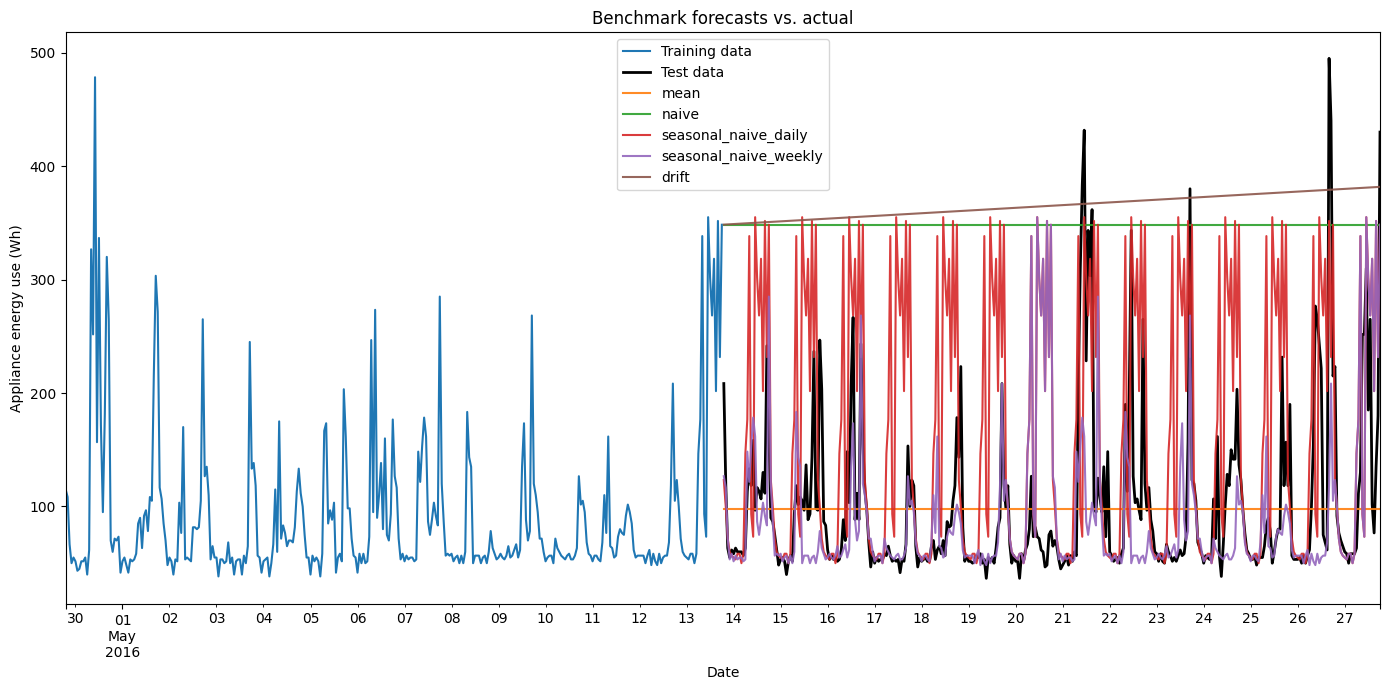

In [5]:
forecast_df = pd.DataFrame({"actual": test})
for name, pred in forecasts.items():
    forecast_df[name] = pred.reindex(test.index)

fig = plotting.plot_forecasts(train, test, forecast_df, title="Benchmark forecasts vs. actual")
plotting.save_fig(fig, config.FIGURE_DIR / "03_benchmark_forecasts.png")
plt.show()

## Save benchmark-only outputs

`scripts/run_pipeline.py` will overwrite `all_forecasts.csv` / `model_comparison.csv` once SARIMAX, the feature-based model, and the foundation model are added in later stages; saving separate benchmark-only files here lets this notebook stand on its own.

In [6]:
forecast_df.to_csv(config.FORECAST_DIR / "benchmark_forecasts.csv")
results_df.to_csv(config.METRICS_DIR / "benchmark_comparison.csv", index=False)
print("Saved benchmark forecasts and metrics.")

Saved benchmark forecasts and metrics.
